In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

from armored.models import *
from armored.preprocessing import *

import itertools

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt


params = {
    'figure.figsize': (7, 5),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 7,            # Font size of the axes labels
    'axes.titlesize': 7,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 7,           # Font size of the x-axis tick labels
    'ytick.labelsize': 7,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 7,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 7,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

In [2]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))

# names of variables
design_vars = [s + " meas" for s in species] + controls

In [3]:
# # predictions for all possible conditions
# pred_df = pd.read_csv("space/space.csv")

# # simulated data
# E_sim = np.array(pred_df.iloc[pred_df.Time.values==0]['Experiments'].values)
# X_sim = np.array(pred_df.iloc[pred_df.Time.values==0][species+controls].values) 
# y_sim = pred_df.iloc[pred_df.Time.values==3]['Objective'].values

# # subsample data 
# subsample_size = 1000
# idx = np.random.choice(len(E_sim), subsample_size, replace=False)
# E = E_sim[idx]
# X = X_sim[idx]
# y = y_sim[idx]

In [5]:
# predictions and measurements for sampled conditions
pred_df = pd.read_csv("space/sampled_space.csv")
pred_df

,Experiments,Time,Diversity meas,Instability meas,Butyrate meas,Objective meas,Diversity pred,Instability pred,Butyrate pred,Objective pred,...,RIabs pred,pH pred,Lactate pred,Acetate pred,AcGum,ArGal,Inulin,Pectin,Starch,Xylan
0,AC-AcGum,0.0,0.0,0.000473,0.000000,NaN,0.0,0.002094,0.000000,-0.039376,...,0.0,6.700000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0
1,AC-AcGum,1.0,0.0,0.000473,NaN,NaN,0.0,0.002094,0.000000,-0.039376,...,0.0,6.764289,0.000000,4.281863,1.0,0.0,0.0,0.0,0.0,0.0
2,AC-AcGum-ArGal-Inulin-Pectin-Starch,0.0,0.0,0.003655,0.000000,NaN,0.0,0.004083,0.000000,0.006240,...,0.0,6.700000,0.000000,0.000000,0.2,0.2,0.2,0.2,0.2,0.0
3,AC-AcGum-ArGal-Inulin-Pectin-Starch,1.0,0.0,0.003655,NaN,NaN,0.0,0.004083,2.009172,0.006240,...,0.0,6.647682,0.000000,8.132391,0.2,0.2,0.2,0.2,0.2,0.0
4,AC-AcGum-ArGal-Inulin-Pectin-Xylan,0.0,0.0,0.004691,0.000000,NaN,0.0,0.004057,0.000000,-0.038517,...,0.0,6.700000,0.000000,0.000000,0.2,0.2,0.2,0.2,0.0,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3961,PC-PJ-Inulin,3.0,0.0,0.000000,0.022342,0.000923,0.0,0.001992,6.505176,0.231296,...,0.0,5.969543,1.013322,11.889233,0.0,0.0,1.0,0.0,0.0,0.0
3962,PJ-Pectin-Xylan,0.0,0.0,0.011316,0.000000,-0.212745,0.0,0.005015,0.000000,-0.044790,...,0.0,6.700000,0.000000,0.000000,0.0,0.0,0.0,0.5,0.0,0.5
3963,PJ-Pectin-Xylan,1.0,0.0,0.011316,0.000000,-0.212745,0.0,0.005015,1.515168,-0.044790,...,0.0,6.591297,1.379595,8.907829,0.0,0.0,0.0,0.5,0.0,0.5
3964,PJ-Pectin-Xylan,2.0,0.0,0.011316,NaN,-0.212745,0.0,0.005015,NaN,-0.044790,...,0.0,6.685699,NaN,NaN,0.0,0.0,0.0,0.5,0.0,0.5


In [18]:
# index of samples at passage 3
t3_inds = np.isin(pred_df.Time.values, 3.)

# objectives
meas_or_pred = 'meas'
diversity = pred_df.iloc[t3_inds][f"Diversity {meas_or_pred}"].values
instability = pred_df.iloc[t3_inds][f"Instability {meas_or_pred}"].values
butyrate = pred_df.iloc[t3_inds][f"Butyrate {meas_or_pred}"].values

In [29]:
# correlations btw objectives
obj_corr = np.corrcoef(np.stack((diversity, instability, butyrate), 0))

# objective labels in order
obj_labels = ['Diversity', 'Instability', 'Butyrate']

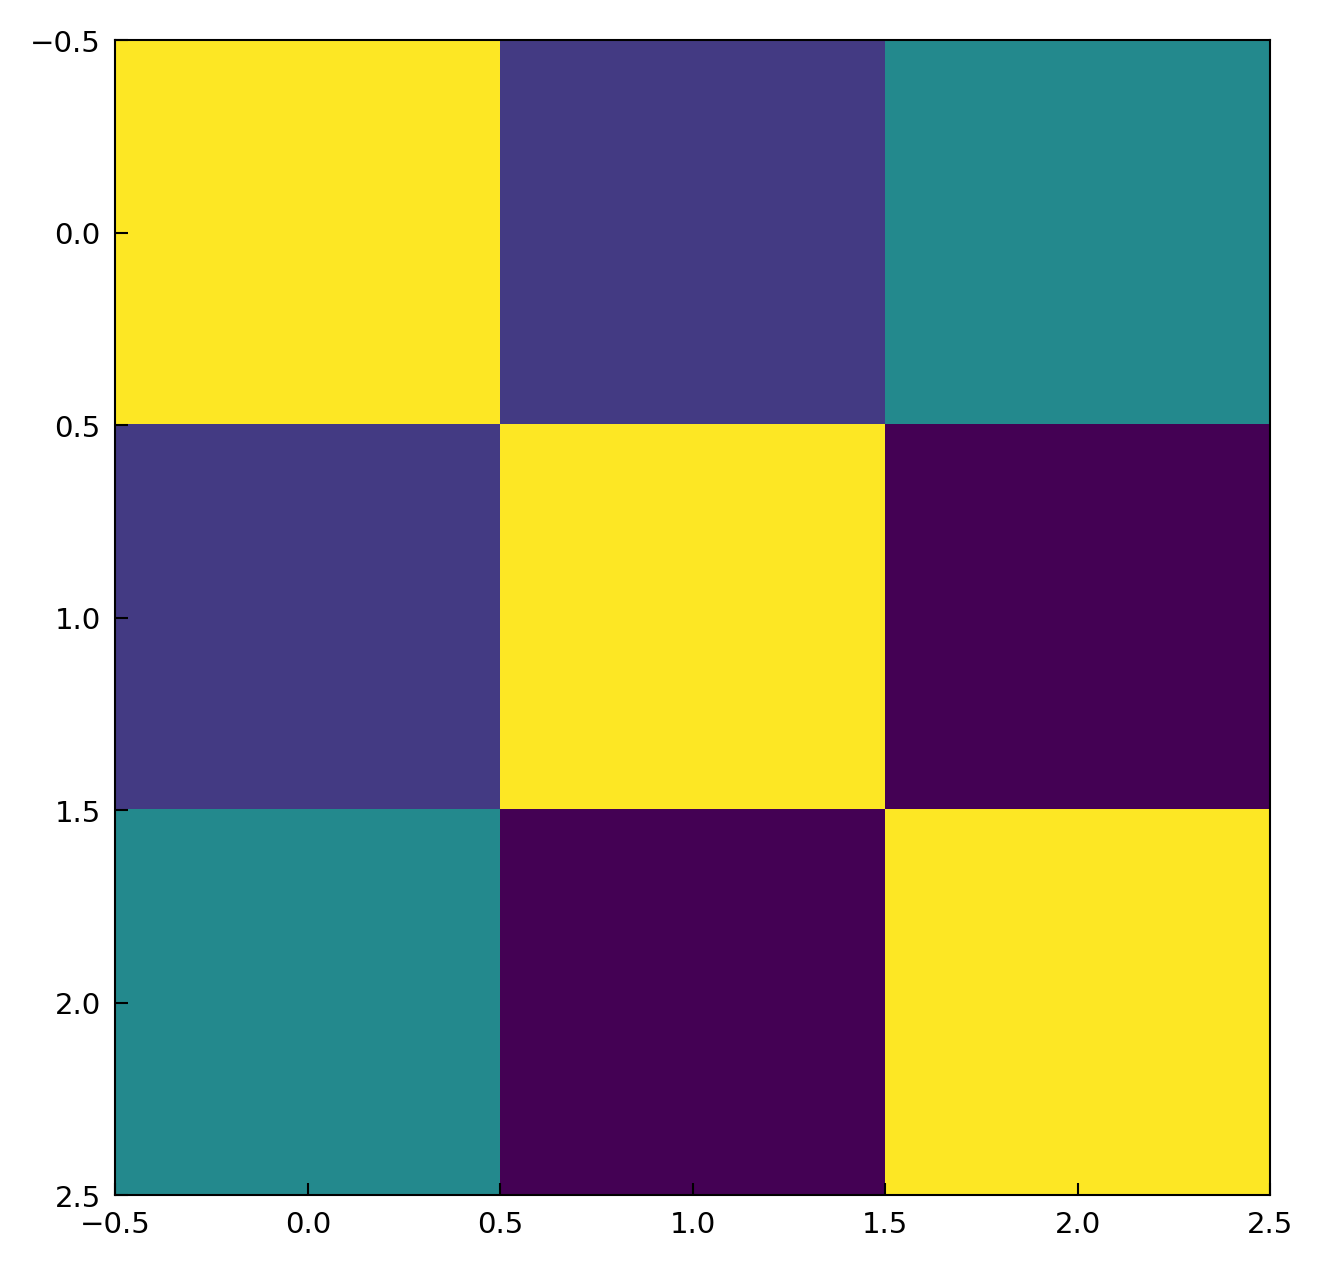

In [30]:
plt.imshow(obj_corr)